# Sampling With Trained Fusion DDPM

This notebook implements **prior sampling** and **posterior sampling** from scratch while keeping the **same U-Net architecture** used during training so you can load `fusion_epoch_2193.pth`.

Posterior sampling below is implemented with a clean **DPS-style data-consistency guidance** (linear tomography / denoising), independent from `utils.py` posterior code.


In [3]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
%load_ext autoreload
%autoreload 2

In [9]:
# ------------------------------
#  Model: same architecture as training
# ------------------------------

def sinusoidal_embedding(n_steps: int, dim: int) -> torch.Tensor:
    positions = torch.arange(n_steps, dtype=torch.float32).unsqueeze(1)
    div_term = torch.pow(10000.0, (2 * torch.arange(dim, dtype=torch.float32)) / dim).unsqueeze(0)
    emb = positions / div_term
    emb[0::2] = torch.sin(emb[0::2])
    emb[1::2] = torch.cos(emb[1::2])
    return emb


class MyConv(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.norm = nn.GroupNorm(1, out_c) if normalize else nn.Identity()
        self.act = nn.SiLU() if activation is None else activation

    def forward(self, x):
        x = self.conv(x)
        x = self.norm(x)
        return self.act(x)


def MyTinyBlock(in_c, out_c):
    return nn.Sequential(
        MyConv(in_c, out_c),
        MyConv(out_c, out_c),
        MyConv(out_c, out_c),
    )


def MyTinyUp(in_c):
    return nn.Sequential(
        MyConv(in_c, in_c // 2),
        MyConv(in_c // 2, in_c // 4),
        MyConv(in_c // 4, in_c // 4),
    )


class MyTinyUNet(nn.Module):
    def __init__(self, in_c=1, out_c=1, n_steps=1000, time_emb_dim=100):
        super().__init__()

        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.weight.requires_grad_(False)

        self.te1 = self._make_te(time_emb_dim, in_c)
        self.b1 = MyTinyBlock(in_c, 10)
        self.down1 = nn.Conv2d(10, 10, kernel_size=4, stride=2, padding=1)

        self.te2 = self._make_te(time_emb_dim, 10)
        self.b2 = MyTinyBlock(10, 20)
        self.down2 = nn.Conv2d(20, 20, kernel_size=4, stride=2, padding=1)

        self.te3 = self._make_te(time_emb_dim, 20)
        self.b3 = MyTinyBlock(20, 40)
        self.down3 = nn.Conv2d(40, 40, kernel_size=4, stride=2, padding=1)

        self.te_mid = self._make_te(time_emb_dim, 40)
        self.b_mid = nn.Sequential(
            MyConv(40, 20),
            MyConv(20, 20),
            MyConv(20, 40),
        )

        self.up1 = nn.ConvTranspose2d(40, 40, kernel_size=4, stride=2, padding=1)
        self.te4 = self._make_te(time_emb_dim, 80)
        self.b4 = MyTinyUp(80)

        self.up2 = nn.ConvTranspose2d(20, 20, kernel_size=4, stride=2, padding=1)
        self.te5 = self._make_te(time_emb_dim, 40)
        self.b5 = MyTinyUp(40)

        self.up3 = nn.ConvTranspose2d(10, 10, kernel_size=4, stride=2, padding=1)
        self.te_out = self._make_te(time_emb_dim, 20)
        self.b_out = MyTinyBlock(20, 10)

        self.conv_out = nn.Conv2d(10, out_c, kernel_size=3, stride=1, padding=1)

    def forward(self, x, t):
        t = t.view(-1)
        te = self.time_embed(t)
        b = x.size(0)

        h1 = self.b1(x + self.te1(te).view(b, -1, 1, 1))
        h2 = self.b2(self.down1(h1) + self.te2(te).view(b, -1, 1, 1))
        h3 = self.b3(self.down2(h2) + self.te3(te).view(b, -1, 1, 1))

        h_mid = self.b_mid(self.down3(h3) + self.te_mid(te).view(b, -1, 1, 1))

        u1 = torch.cat([h3, self.up1(h_mid)], dim=1)
        u1 = self.b4(u1 + self.te4(te).view(b, -1, 1, 1))

        u2 = torch.cat([h2, self.up2(u1)], dim=1)
        u2 = self.b5(u2 + self.te5(te).view(b, -1, 1, 1))

        u3 = torch.cat([h1, self.up3(u2)], dim=1)
        u3 = self.b_out(u3 + self.te_out(te).view(b, -1, 1, 1))

        return self.conv_out(u3)

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out),
        )


In [10]:
# ------------------------------
#  Diffusion schedule + samplers (from scratch)
# ------------------------------

def build_schedule(num_train_steps=1000, beta_start=1e-4, beta_end=2e-2, device=device):
    betas = torch.linspace(beta_start, beta_end, num_train_steps, device=device, dtype=torch.float32)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return {
        "num_train_steps": num_train_steps,
        "betas": betas,
        "alphas": alphas,
        "alpha_bar": alpha_bar,
    }


def make_timesteps(num_train_steps, num_inference_steps):
    return np.linspace(num_train_steps - 1, 0, num_inference_steps, dtype=np.int64).tolist()


def predict_x0_from_eps(x_t, eps_t, alpha_bar_t):
    return (x_t - torch.sqrt(1 - alpha_bar_t) * eps_t) / torch.sqrt(alpha_bar_t)


def ddim_update(x0_hat, eps_t, t, t_prev, alpha_bar, eta=0.0):
    if t_prev < 0:
        return x0_hat

    a_t = alpha_bar[t]
    a_prev = alpha_bar[t_prev]

    sigma_t = eta * torch.sqrt((1 - a_prev) / (1 - a_t) * (1 - a_t / a_prev))
    c_t = torch.sqrt(torch.clamp(1 - a_prev - sigma_t**2, min=0.0))
    noise = torch.randn_like(x0_hat) if eta > 0 else torch.zeros_like(x0_hat)

    x_prev = torch.sqrt(a_prev) * x0_hat + c_t * eps_t + sigma_t * noise
    return x_prev


def apply_A(A, x):
    # x: [B,1,H,W], A: [m,n] with n=H*W
    return x.flatten(1) @ A.T


def apply_At(A, v):
    # v: [B,m], A: [m,n]
    return v @ A


@torch.no_grad()
def sample_prior(
    model,
    schedule,
    image_shape=(1, 120, 40),
    num_samples=8,
    num_inference_steps=250,
    eta=0.0,
    clip_range=None,
):
    model.eval()
    x = torch.randn(num_samples, *image_shape, device=device)

    timesteps = make_timesteps(schedule["num_train_steps"], num_inference_steps)
    alpha_bar = schedule["alpha_bar"]

    for i, t in enumerate(tqdm(timesteps, desc="Prior sampling")):
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)

        eps_t = model(x, t_batch)
        x0_hat = predict_x0_from_eps(x, eps_t, alpha_bar[t])

        if clip_range is not None:
            x0_hat = x0_hat.clamp(*clip_range)

        x = ddim_update(x0_hat, eps_t, t, t_prev, alpha_bar, eta=eta)

    return x


@torch.no_grad()
def sample_posterior_dps(
    model,
    schedule,
    A,
    y,
    image_shape=(1, 120, 40),
    num_samples=8,
    num_inference_steps=250,
    eta=0.0,
    sigma_y=0.05,
    guidance_scale=0.2,
    clip_range=None,
    x_init=None,
):
    """
    DPS-style posterior sampling with linear observations y = A x + n.

    Guidance acts on x0 estimate:
        x0 <- x0 - step_t * grad_x0 ||A x0 - y||^2
    then the diffusion transition uses guided x0.
    """
    model.eval()
    alpha_bar = schedule["alpha_bar"]
    diffusion_process = []  # to store intermediate samples for visualization
    if x_init is None:
        x = torch.randn(num_samples, *image_shape, device=device)
    else:
        x = x_init.to(device)
        if x.dim() == 3:
            x = x.unsqueeze(0)
        if x.size(0) == 1 and num_samples > 1:
            x = x.repeat(num_samples, 1, 1, 1)

    if y.dim() == 1:
        y = y.unsqueeze(0)

    timesteps = make_timesteps(schedule["num_train_steps"], num_inference_steps)
    residual_history = []

    for i, t in enumerate(tqdm(timesteps, desc="Posterior sampling")):
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)

        eps_t = model(x, t_batch)
        x0_hat = predict_x0_from_eps(x, eps_t, alpha_bar[t])

        pred_y = apply_A(A, x0_hat)
        residual = pred_y - y

        grad_x0 = apply_At(A, residual) / (sigma_y**2 * A.shape[0])
        grad_x0 = grad_x0.view_as(x0_hat)

        step_t = guidance_scale * torch.sqrt(1 - alpha_bar[t])
        grad_norm = grad_x0.flatten(1).norm(dim=1, keepdim=True).view(-1, 1, 1, 1).clamp_min(1e-8)
        x0_guided = x0_hat - step_t * grad_x0 / grad_norm

        if clip_range is not None:
            x0_guided = x0_guided.clamp(*clip_range)

        x = ddim_update(x0_guided, eps_t, t, t_prev, alpha_bar, eta=eta)
        residual_history.append(residual.norm(dim=1).mean().item())
        diffusion_process.append(x0_guided[0].detach().cpu())

    return x, residual_history, diffusion_process

@torch.no_grad()
def sample_posterior_diffpir(
    model,
    schedule,
    A,
    y,
    image_shape=(1, 120, 40),
    num_samples=8,
    num_inference_steps=250,
    zeta=0.0,
    sigma_y=0.05,
    lambda_=0.2,
    clip_range=None,
    x_init=None,
):
    """
    DPS-style posterior sampling with linear observations y = A x + n.

    Guidance acts on x0 estimate:
        x0 <- x0 - step_t * grad_x0 ||A x0 - y||^2
    then the diffusion transition uses guided x0.
    """
    zeta = torch.tensor(zeta, device=device)
    model.eval()
    alpha_bar = schedule["alpha_bar"]
    diffusion_process = []  # to store intermediate samples for visualization
    if x_init is None:
        x = torch.randn(num_samples, *image_shape, device=device)
    else:
        x = x_init.to(device)
        if x.dim() == 3:
            x = x.unsqueeze(0)
        if x.size(0) == 1 and num_samples > 1:
            x = x.repeat(num_samples, 1, 1, 1)

    if y.dim() == 1:
        y = y.unsqueeze(0)

    timesteps = make_timesteps(schedule["num_train_steps"], num_inference_steps)
    residual_history = []

    for i, t in enumerate(tqdm(timesteps, desc="Posterior sampling")):
        sigma_t_bar = torch.sqrt((1 - alpha_bar[t]) / alpha_bar[t])
        rho_t = lambda_ * (sigma_y**2 / sigma_t_bar**2)

        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)

        eps_model = model(x, t_batch)
        x0_hat = predict_x0_from_eps(x, eps_model, alpha_bar[t])

        Id_matrix = torch.eye(A.shape[1], device=A.device)
        H = A.T @ A + rho_t * Id_matrix
        b = apply_At(A, y) + rho_t * x0_hat.view(x0_hat.size(0), -1)
        x0_guided = torch.linalg.solve(H, b.T).T.view_as(x0_hat)

        x = ddim_update(x0_guided, eps_model, t, t_prev, alpha_bar, eta=zeta)

        pred_y = apply_A(A, x0_hat)
        residual = pred_y - y
        residual_history.append(residual.norm(dim=1).mean().item())
        diffusion_process.append(x0_guided[0].detach().cpu())

    return x, residual_history, diffusion_process

def show_samples(samples, title, ncols=4, vmin=None, vmax=None):
    samples = samples.detach().cpu()
    n = samples.size(0)
    ncols = min(ncols, n)
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(len(axes)):
        axes[i].axis("off")
        if i < n:
            axes[i].imshow(samples[i, 0], cmap="gray", vmin=vmin, vmax=vmax)
            axes[i].set_title(f"sample {i}")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [11]:
# ------------------------------
#  Load checkpoint
# ------------------------------

weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")


missing keys: 0
unexpected keys: 0


Prior sampling: 100%|██████████| 250/250 [00:02<00:00, 97.11it/s] 


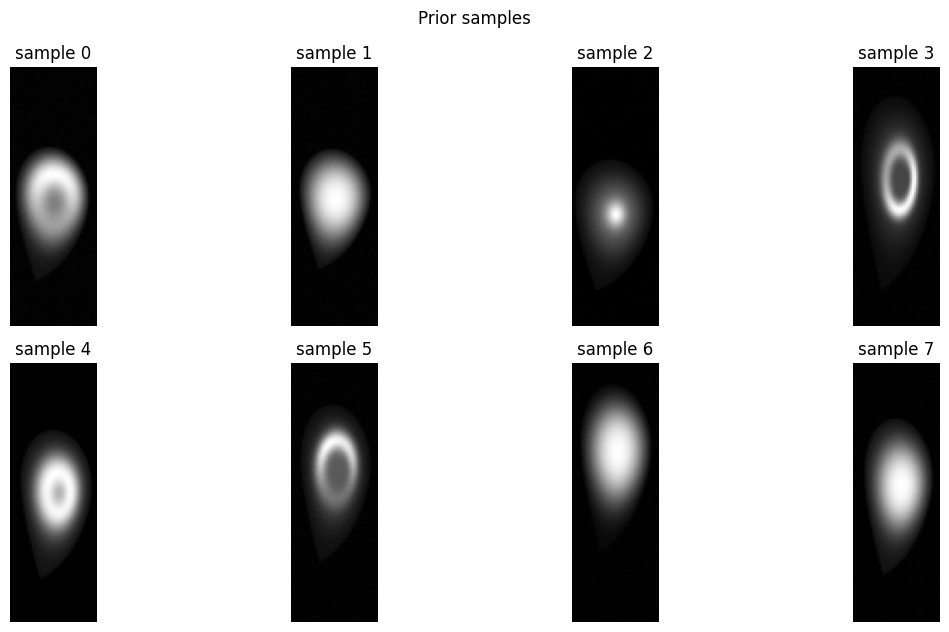

In [13]:
# ------------------------------
#  Prior sampling
# ------------------------------

H, W = 120, 40

prior_samples = sample_prior(
    model=model,
    schedule=schedule,
    image_shape=(1, H, W),
    num_samples=99,
    num_inference_steps=250,   # increase to 1000 for full schedule
    eta=0.0,                   # 0: deterministic DDIM, >0: more stochastic
    clip_range=None,
)

show_samples(prior_samples[:8], title="Prior samples")

Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy


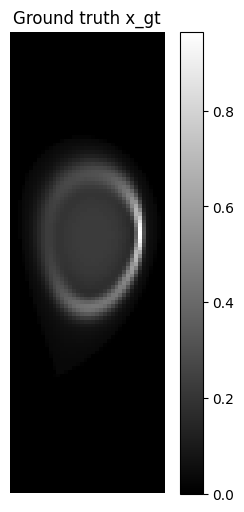

In [181]:
# ------------------------------
#  Build a ground-truth image x_gt
# ------------------------------
# Option A: load one training-like SXR profile from your local dataset path.
# Option B (fallback): use one prior sample as synthetic x_gt.

sample_idx = 2#122
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]

x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx]
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

if x_gt is None:
    x_gt = prior_samples[:1].clone()
    print("No local sxr_sample_*.npy found. Using first prior sample as x_gt fallback.")

plt.figure(figsize=(4, 6))
plt.imshow(x_gt[0, 0].detach().cpu(), cmap="gray")
plt.colorbar()
plt.title("Ground truth x_gt")
plt.axis("off")
plt.show()


In [188]:
# path_train_data =   Path(f"../../data/sxr_data/sxr_profiles_coarse")
# train_data_max = []
# i=0
# for p in path_train_data.glob("*.npy"):
#     train_data_max.append(np.load(p).max())
#     i += 1
#     if i >= 10000:  # limit to first 100 files for speed
#         break

# print(np.array(train_data_max).mean(), np.array(train_data_max).std(), np.array(train_data_max).max(), np.array(train_data_max).min())

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

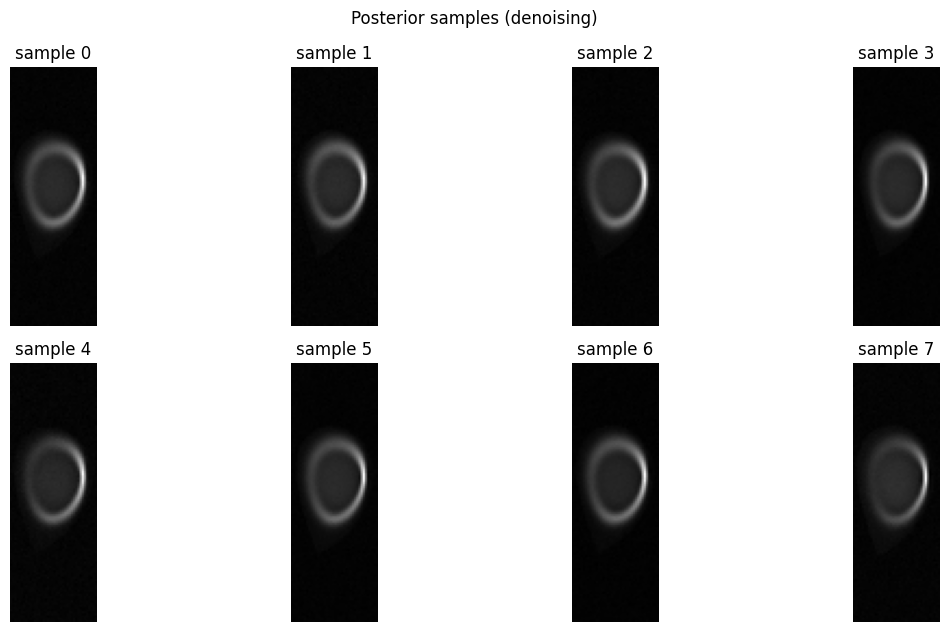

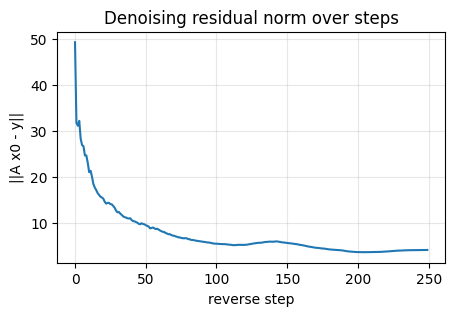

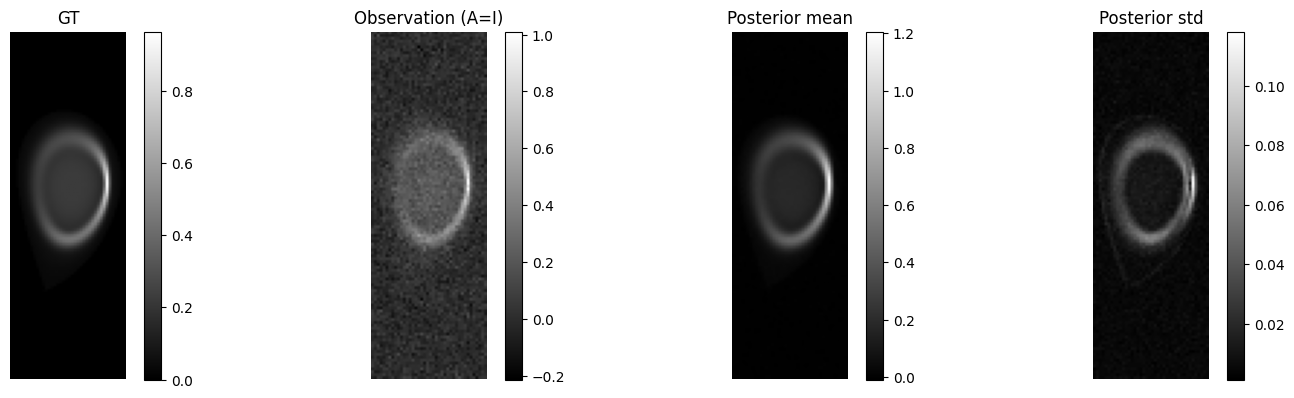

In [93]:
# ------------------------------
#  Posterior sampling: denoising (A = I)
# ------------------------------

n = H * W
A_denoise = torch.eye(n, device=device)

sigma_y_denoise = 0.05
y_denoise = x_gt.flatten() + sigma_y_denoise * torch.randn(n, device=device)

posterior_denoise, denoise_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_denoise,
    y=y_denoise,
    image_shape=(1, H, W),
    num_samples=8,
    num_inference_steps=250,
    zeta=0.6,
    sigma_y=sigma_y_denoise,
    lambda_=3000,
    clip_range=None,
)

show_samples(posterior_denoise[:8], title="Posterior samples (denoising)")

plt.figure(figsize=(5, 3))
plt.plot(denoise_residuals)
plt.title("Denoising residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()

# Compare denoising result: GT vs observation vs posterior stats
post_mean_denoise = posterior_denoise.mean(dim=0, keepdim=True)
post_std_denoise = posterior_denoise.std(dim=0, keepdim=True)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

im0 = ax[0].imshow(x_gt[0, 0].detach().cpu(), cmap="gray")
ax[0].set_title("GT")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(y_denoise.view(H, W).detach().cpu(), cmap="gray")
ax[1].set_title("Observation (A=I)")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(post_mean_denoise[0, 0].detach().cpu(), cmap="gray")
ax[2].set_title("Posterior mean")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

im3 = ax[3].imshow(post_std_denoise[0, 0].detach().cpu(), cmap="gray")
ax[3].set_title("Posterior std")
plt.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

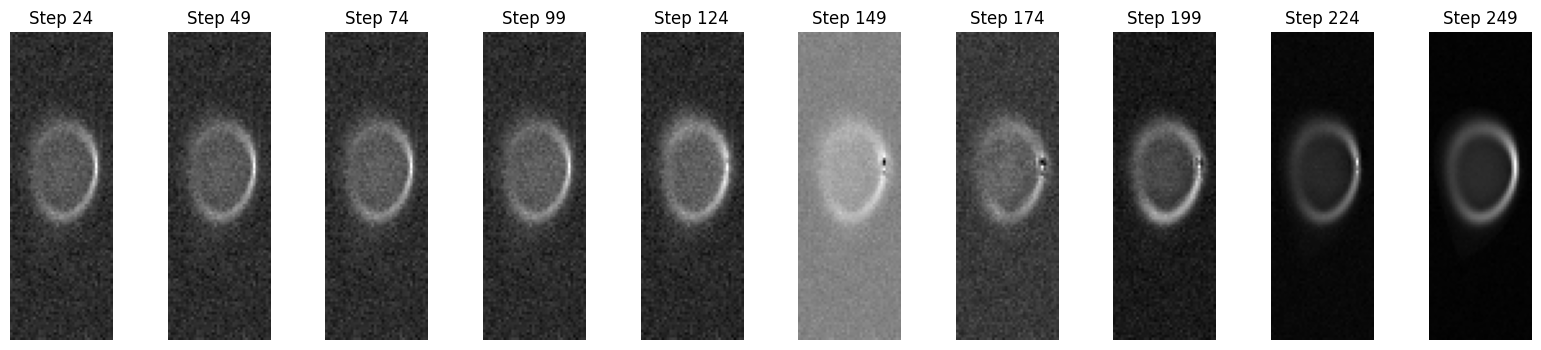

In [94]:
diffusion_process = np.array(diffusion_process)  # [num_steps, H, W]
fig, ax = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    idx = int((i+1) * len(diffusion_process) / 10 -1)
    ax[i].imshow(diffusion_process[idx,0], cmap="gray")
    ax[i].set_title(f"Step {idx}")
    ax[i].axis("off")

A_tomo: (100, 4800)


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

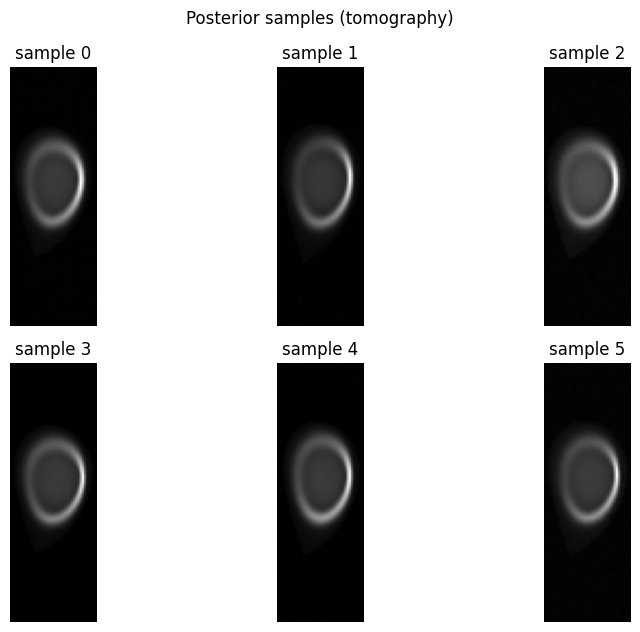

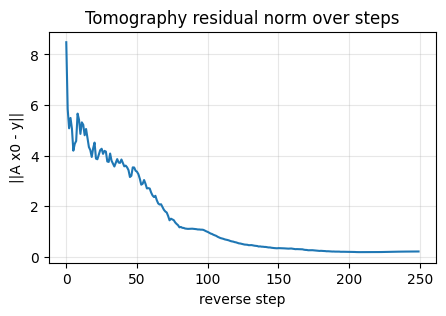

In [137]:
# ------------------------------
#  Posterior sampling: tomography (A from forward model)
# ------------------------------

A_path = Path("forward_model/forward_model_sxr_full_geometry.npy") # sparse_mat_artificial_coarse_random_1e4.npz or sparse_geometry_matrix_sxr.npz or forward_model_sxr_full_geometry.npy
assert A_path.exists(), f"Missing forward matrix: {A_path}"

A_sparse = np.load(A_path).astype(np.float32) * 1e9 # rescale if forward_model_sxr_full_geometry
A_tomo = torch.from_numpy(A_sparse).to(device)
print("A_tomo:", tuple(A_tomo.shape))

sigma_y_tomo = 0.01
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)

posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.6,
    sigma_y=sigma_y_tomo,
    lambda_=3000,  
    clip_range=None,
)

# posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_dps(
#     model=model,
#     schedule=schedule,
#     A=A_tomo,
#     y=y_tomo,
#     image_shape=(1, H, W),
#     num_samples=100,
#     num_inference_steps=250,
#     eta=0., # 0 for sparse_mat_artificial_coarse_random_1e4
#     sigma_y=sigma_y_tomo,
#     guidance_scale=0.5,  # 0.3 for sparse_mat_artificial_coarse_random_1e4 model
#     clip_range=None,
# )

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=3)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


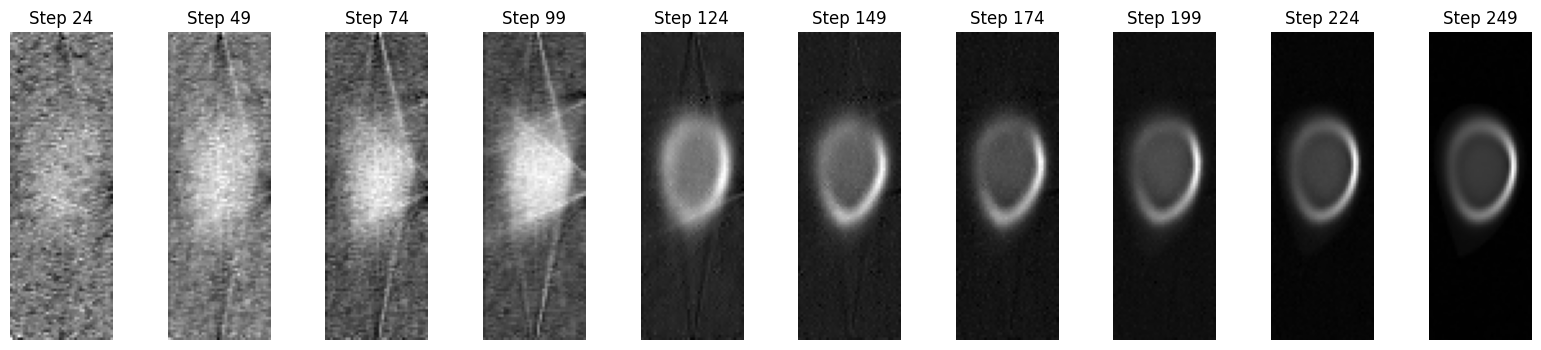

In [138]:
diffusion_process = np.array(diffusion_process)  # [num_steps, H, W]
fig, ax = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    idx = int((i+1) * len(diffusion_process) / 10 -1)
    ax[i].imshow(diffusion_process[idx,0], cmap="gray")
    ax[i].set_title(f"Step {idx}")
    ax[i].axis("off")

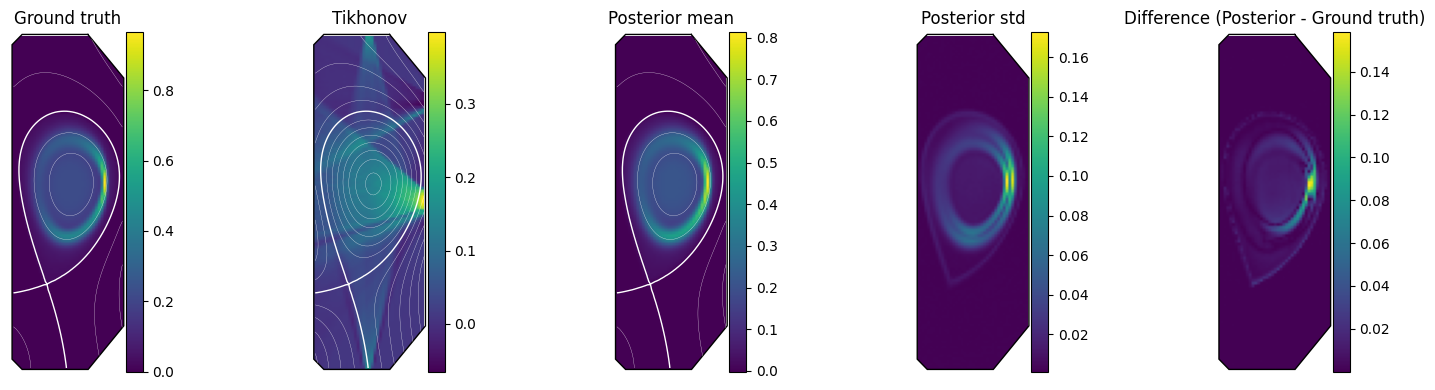

In [144]:
# ------------------------------
#  Posterior summary + baseline
# ------------------------------

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std = posterior_tomo.std(dim=0, keepdim=True)

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA = A_tomo.T @ A_tomo
Aty = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)


psi=np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx, :,:]

fig, ax = plt.subplots(1, 5, figsize=(16, 4))

tomo_plots.plot_profile(np.array(x_gt[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=psi[:, :], levels=5,
                            cmap="viridis", ax=ax[0], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[0].set_title("Ground truth")

tomo_plots.plot_profile(np.array(x_tikh[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=psi[:, :],
                            cmap="viridis", ax=ax[1], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[1].set_title("Tikhonov")

tomo_plots.plot_profile(np.array(post_mean[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=psi[:, :], levels=5,
                            cmap="viridis", ax=ax[2], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[2].set_title("Posterior mean")

tomo_plots.plot_profile(np.array(post_std[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=None,
                            cmap="viridis", ax=ax[3], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[3].set_title("Posterior std")

tomo_plots.plot_profile(np.abs(np.array((post_mean - x_gt)[0, 0].detach().cpu())), tcv_plot_clip=True, contour_image=None,
                            cmap="viridis", ax=ax[4], colorbar=True, contour_color="k", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[4].set_title("Difference (Posterior - Ground truth)")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## Notes for Tuning

- `num_inference_steps`: start with `250`; increase toward `1000` for higher fidelity.
- `guidance_scale`: higher values enforce measurement consistency more strongly.
- `sigma_y`: set close to your measurement noise std.
- `eta`: `0.0` is deterministic; positive values add stochasticity.

If posterior still underfits measurements, increase `guidance_scale` gradually (for example `0.30 -> 0.50 -> 0.80`).


## REAL DATA SHOT

In [57]:
from scipy import ndimage

def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        # convert inversion grid coordinates to image coordinates
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            # for doublet, flip the original equilibrium to match the new grid orientation
             eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                            coord_eval_pos, order=2, mode="nearest",
                                                            prefilter=True).reshape(Nz, Nr)
        else:
            # evaluate original fbte input on the prescribed inversion grid
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                                coord_eval_pos, order=2, mode="nearest",
                                                                prefilter=True).reshape(Nz, Nr)
    return eqs

In [80]:
import scipy.io as scio
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

# exp_data = scio.loadmat('experimental_data/shot_data_85270.mat')['data'][0, 0] # singlet
# psi=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=False)
exp_data = scio.loadmat('experimental_data/shot_data_87262.mat')['data'][0, 0] # doublet
psi=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=True)
exp_data.dtype

dtype([('etendues', 'O'), ('good_channels', 'O'), ('measurements', 'O'), ('measurements_times', 'O'), ('psi', 'O'), ('liuqe_rs', 'O'), ('liuqe_zs', 'O')])

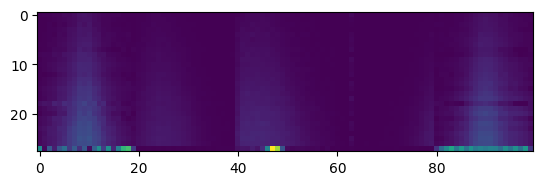

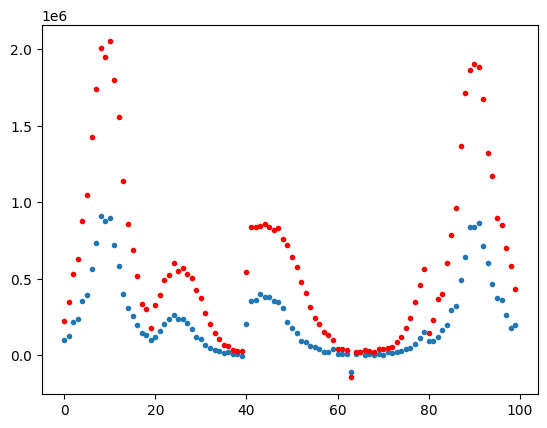

In [81]:
plt.imshow(np.abs(exp_data["measurements"]))
#plt.yticks([0,10,20], labels=[str(exp_data["measurements_times"].flatten()[0]), str(exp_data["measurements_times"].flatten()[10]), str(exp_data["measurements_times"].flatten()[20])])
plt.show()

plt.plot(exp_data["measurements"][10,:], '.')
plt.plot(exp_data["measurements"][26,:], 'r.')

A_tomo: (99, 4800)


Posterior sampling: 100%|██████████| 250/250 [00:08<00:00, 28.01it/s]


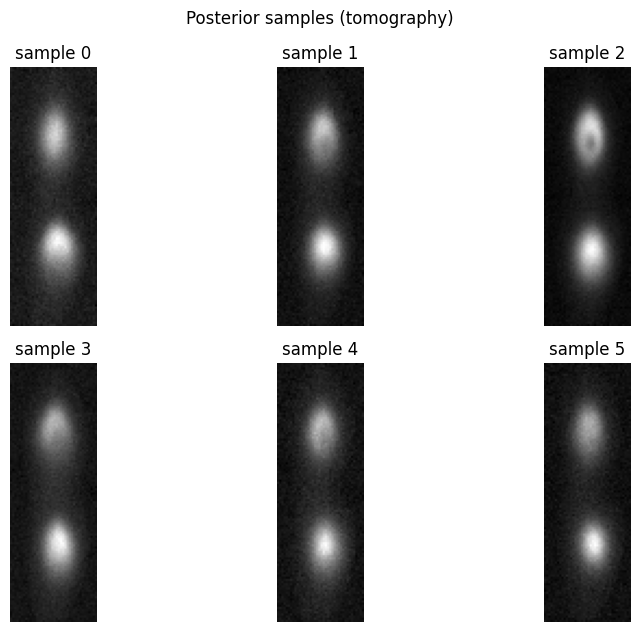

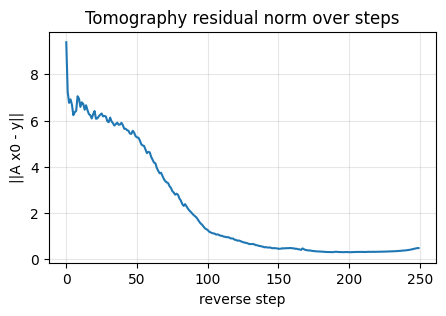

In [84]:
# ------------------------------
#  Posterior sampling: tomography (A from forward model)
# ------------------------------


A_path = Path("forward_model/forward_model_sxr_full_geometry.npy") # sparse_mat_artificial_coarse_random_1e4.npz or sparse_geometry_matrix_sxr.npz or forward_model_sxr_full_geometry.npy
assert A_path.exists(), f"Missing forward matrix: {A_path}"

good_channels = exp_data['good_channels'].flatten() - 1
#good_channels = np.setdiff1d(good_channels, np.array([20,21,22,23]))

A_sparse = np.load(A_path).astype(np.float32) * 1e9 # rescale if forward_model_sxr_full_geometry
A_sparse = A_sparse[good_channels, :] # remove faulty channels
A_tomo = torch.from_numpy(A_sparse).to(device)
print("A_tomo:", tuple(A_tomo.shape))

exp_idx= 26 # 5, 10, 26
y_tomo = np.array(exp_data["measurements"][exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) 
y_tomo = y_tomo[good_channels] # remove faulty channels
y_tomo = torch.from_numpy(y_tomo).to(device=device, dtype=torch.float32)
y_tomo /= torch.max(y_tomo)


sigma_y_tomo = 0.01

posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.6,
    sigma_y=sigma_y_tomo,
    lambda_=2000,  
    clip_range=None,
)

# sigma_real_data = 0.01
# posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_dps(
#     model=model,
#     schedule=schedule,
#     A=A_tomo,
#     y=y_tomo,
#     image_shape=(1, H, W),
#     num_samples=100,
#     num_inference_steps=250,
#     eta=0., # 0 for sparse_mat_artificial_coarse_random_1e4
#     sigma_y=sigma_real_data,
#     guidance_scale=0.6,  # 0.3 for sparse_mat_artificial_coarse_random_1e4 model
#     clip_range=None,
# )

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=3)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


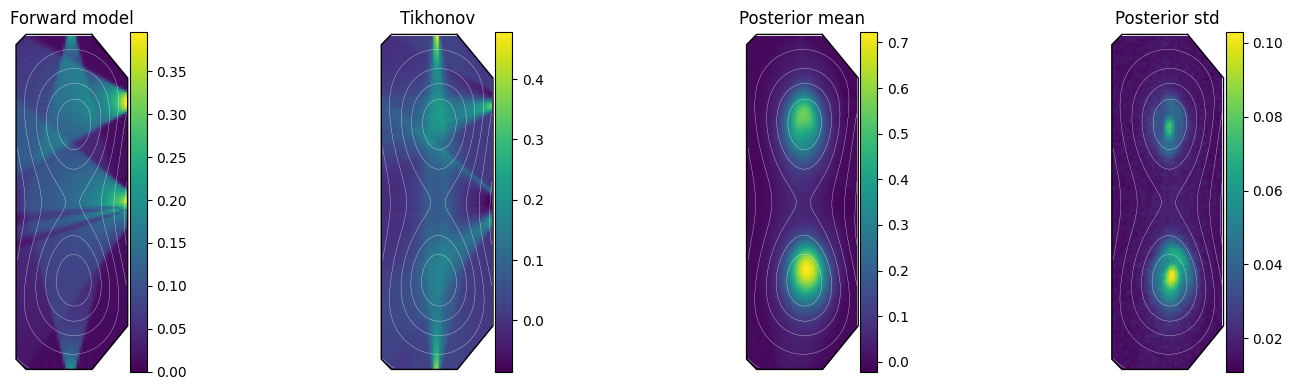

In [85]:
# ------------------------------
#  Posterior summary + baseline
# ------------------------------

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std = posterior_tomo.std(dim=0, keepdim=True)

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA = A_tomo.T @ A_tomo
Aty = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

tomo_plots.plot_profile(np.sum(np.array(A_tomo.detach().cpu()),0).reshape(120,40), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=ax[0], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[0].set_title("Forward model")

tomo_plots.plot_profile(np.array(x_tikh[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=ax[1], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)

ax[1].set_title("Tikhonov")
tomo_plots.plot_profile(np.array(post_mean[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :], levels = 5,
                            cmap="viridis", ax=ax[2], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[2].set_title("Posterior mean")
tomo_plots.plot_profile(np.array((post_std[0, 0].detach().cpu())), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=ax[3], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)  
ax[3].set_title("Posterior std")


for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

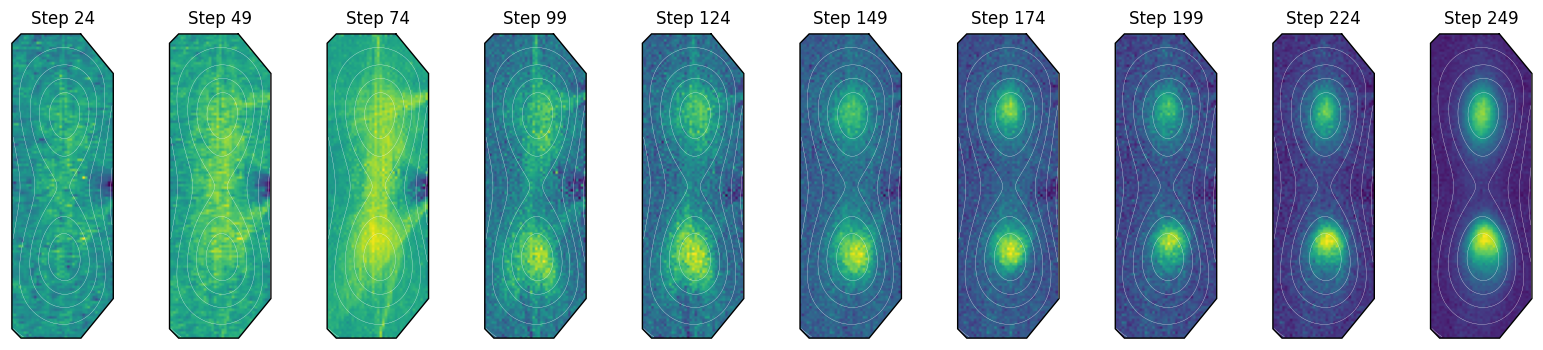

In [86]:
#plot diffusion process
diffusion_process = np.array(diffusion_process)  # [num_steps, H, W
fig, ax = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    idx = int((i+1) * len(diffusion_process) / 10 -1)
    tomo_plots.plot_profile(diffusion_process[idx,0], tcv_plot_clip=True, contour_image=psi[exp_idx, :, :], levels=5,
                            cmap="viridis", ax=ax[i], colorbar=False, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
    ax[i].set_title(f"Step {idx}")
    ax[i].axis("off")

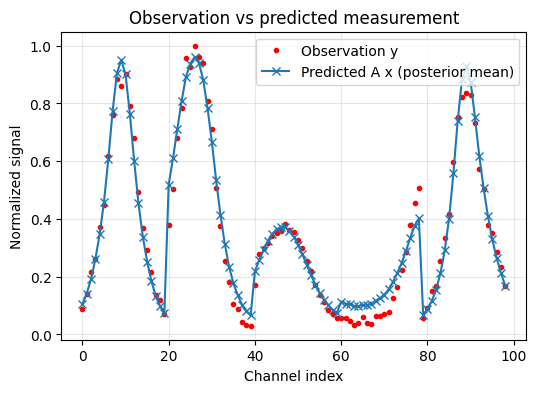

In [87]:
# plot Ax and y
with torch.no_grad():
    Ax = apply_A(A_tomo, post_mean).cpu().numpy()
    y_np = y_tomo.cpu().numpy()
plt.figure(figsize=(6, 4))
plt.plot(y_np.flatten(), 'r.', label='Observation y')
plt.plot(Ax.flatten(), 'x-', label='Predicted A x (posterior mean)')
plt.legend()
plt.title("Observation vs predicted measurement")
plt.xlabel("Channel index")
plt.ylabel("Normalized signal")
plt.grid(True, alpha=0.3)

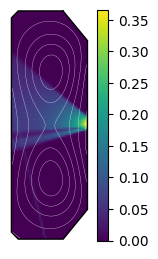

In [88]:
tomo_plots.plot_profile(np.sum(np.array(A_tomo.detach().cpu())[60:80, :],0).reshape(120,40), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=None, colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)

# Reaction -diffusion

In [108]:
import numpy as np
import scipy.sparse as sp
import copy
from scipy import ndimage
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu.info import ptype as pxt
from pyxu.abc.operator import LinOp
import scipy.io as scio
import warnings
from pyxu_diffops.operator import AnisDiffusionOp

sigma_err = 0.05
anis_param = 1e-2
reg_param = 1e-1
with_positivity_constraint = True

#noisy_tomo_data = apply_A(A_tomo, post_mean).cpu().numpy().reshape(1,-1) # doublet
noisy_tomo_data = y_tomo.cpu().numpy().reshape(1,-1)

f = fct_def._DataFidelityFunctional(dim_shape=(1, 120, 40), noisy_tomo_data=noisy_tomo_data,
                                    sigma_err=sigma_err, geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy()))
g = AnisDiffusionOp(dim_shape=(1, 120, 40),
                            alpha=anis_param,
                            diff_method_struct_tens="fd",
                            freezing_arr=psi,
                            sampling=0.0125,
                            matrix_based_impl=True)
# compute core mask
#core_mask=np.zeros((120,40),dtype=bool)
#core_mask[np.where(psi[exp_idx,:,:]<0)]=True
#core_mask[90:,:]=False
# cmopute MAP
im_map = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=with_positivity_constraint, clipping_mask=None,
                            show_progress=False)


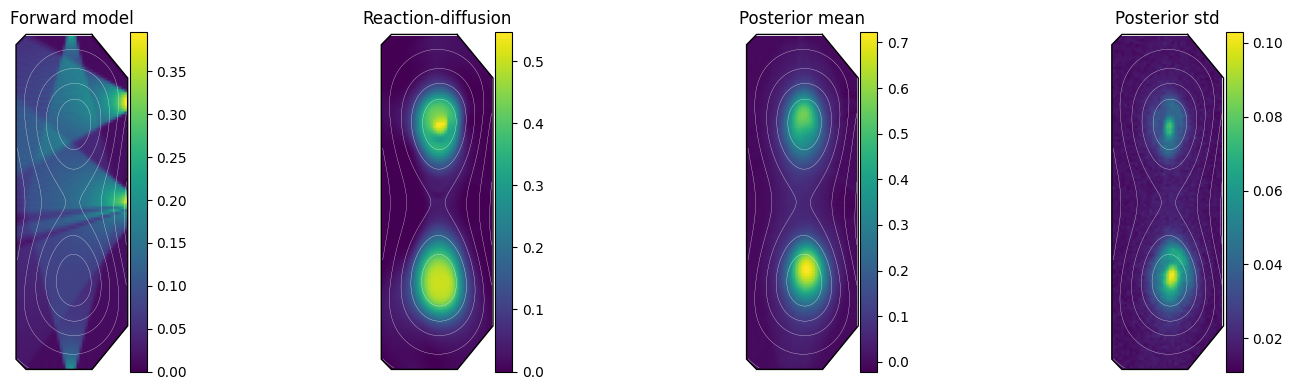

In [109]:
# ------------------------------
#  Posterior summary + baseline
# ------------------------------

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std = posterior_tomo.std(dim=0, keepdim=True)

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA = A_tomo.T @ A_tomo
Aty = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

tomo_plots.plot_profile(np.sum(np.array(A_tomo.detach().cpu()),0).reshape(120,40), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=ax[0], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[0].set_title("Forward model")

tomo_plots.plot_profile(im_map, tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=ax[1], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)

ax[1].set_title("Reaction-diffusion")
tomo_plots.plot_profile(np.array(post_mean[0, 0].detach().cpu()), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :], levels = 5,
                            cmap="viridis", ax=ax[2], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)
ax[2].set_title("Posterior mean")
tomo_plots.plot_profile(np.array((post_std[0, 0].detach().cpu())), tcv_plot_clip=True, contour_image=psi[exp_idx, :, :],levels = 5,
                            cmap="viridis", ax=ax[3], colorbar=True, contour_color="w", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)  
ax[3].set_title("Posterior std")


for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()